<a href="https://colab.research.google.com/github/zohrehasadi00/automatic_image_analysis/blob/main/notebooks/SkinLesionTriage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reproducible Pipeline

In [45]:
# import collection

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from scipy.sparse import find

In [46]:
#set seed for reproducibility
random_state = 42
torch.manual_seed(42)

In [47]:
# connect Drive for data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Data Exploration

In this section you will find:


*   the classification labels (malignant and benign) are converted into numerical values
* a sanity check is conducted to ensure that no image files listed in the metadata are missing
* descriptive statistic on the distribution of the complete dataset




In [48]:
#path to image data
data_raw =[
    '/content/drive/MyDrive/AIA_SkinLesion_Projekt/data/raw/HAM10000_images_part_1',
    '/content/drive/MyDrive/AIA_SkinLesion_Projekt/data/raw/HAM10000_images_part_2'
    ]

# load metadata
csv_path = '/content/drive/MyDrive/AIA_SkinLesion_Projekt/HAM10000_metadata.csv'
df_metadata = pd.read_csv(csv_path)


In [61]:
##### Recode 'mel' (melanoma) = 1, benign = 0 #####

df_metadata['label'] = (df_metadata['dx'] == 'mel').astype(int)

#save converted file back to Drive
output_dir = '/content/drive/MyDrive/AIA_SkinLesion_Projekt'
os.makedirs(output_dir, exist_ok=True)

df_metadata.to_csv(os.path.join(output_dir, 'metadata_converted.csv'), index=False)


In [60]:
##### Sanity check for missing image files #####
missing = []

for idx in range(len(df_metadata)):
    img_id = df_metadata.iloc[idx]['image_id']
    img_name = img_id + '.jpg'
    found = any(os.path.exists(os.path.join(d, img_name)) for d in data_raw)
    if not found:
        missing.append(img_name)

print(f"{len(missing)} images could not be found")
print(missing[:10])




0 images could not be found
[]


Shape of data : (10015, 8)
Nummber of dimensions : 2

Class distribution (0=benign, 1=melanoma):
label
0    8902
1    1113
Name: count, dtype: int64


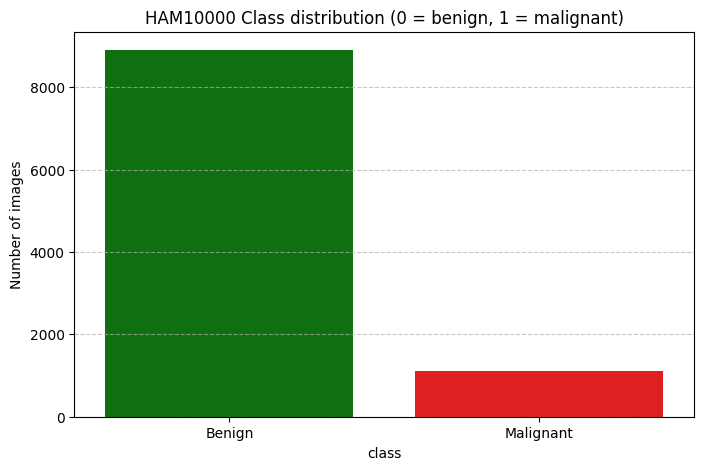


Impression of the data:


,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,0
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,0
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,0
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,0
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,0


In [58]:
##### plot class distribution #####
def plotClassDistribution(dataset):
  plt.figure(figsize=(8, 5))
  sns.countplot(x='label', data=dataset, hue='label', palette=['green', 'red'], legend=False)
  plt.title('HAM10000 Class distribution (0 = benign, 1 = malignant)')
  plt.xlabel('class')
  plt.ylabel('Number of images')
  plt.xticks([0, 1], ['Benign', 'Malignant'])
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()


print(f"Shape of data : {df_metadata.shape}")
print(f"Nummber of dimensions : {df_metadata.ndim}")
print(f"\nClass distribution (0=benign, 1=melanoma):\n{df_metadata['label'].value_counts()}")
plotClassDistribution(df_metadata)

print(f"\nImpression of the data:")
df_metadata.head()


# Split training, test and validation set

In this section the data is split to train, validation and test set. All splits are saved in distinct csv-files on Drive, so that we can use for both pipelines the same splits.

**Train set**: Is used for training

**Validation set** (12.5% of the train set): Is used for hyperparameter training

**Test set** (20% of the original dataset): Is used for evaluating the model's performance


In [52]:

train_val_df, test_df = train_test_split(df_metadata, test_size=0.20, stratify=df_metadata['label'], random_state=random_state) # set seed

# create validation set for hyperparameter fine tuning
train_df, val_df = train_test_split(train_val_df, test_size=0.125, stratify=train_val_df['label'], random_state=random_state)

print(f"training set: {len(train_df)}")
print(f"validation set: {len(val_df)}")
print(f"test set: {len(test_df)}")

##save split sets to Drive
output_dir = '/content/drive/MyDrive/AIA_SkinLesion_Projekt/splits'
os.makedirs(output_dir, exist_ok=True)

train_df.to_csv(os.path.join(output_dir, 'train.csv'), index=False)
val_df.to_csv(os.path.join(output_dir, 'val.csv'), index=False)
test_df.to_csv(os.path.join(output_dir, 'test.csv'), index=False)

training set: 7010
validation set: 1002
test set: 2003


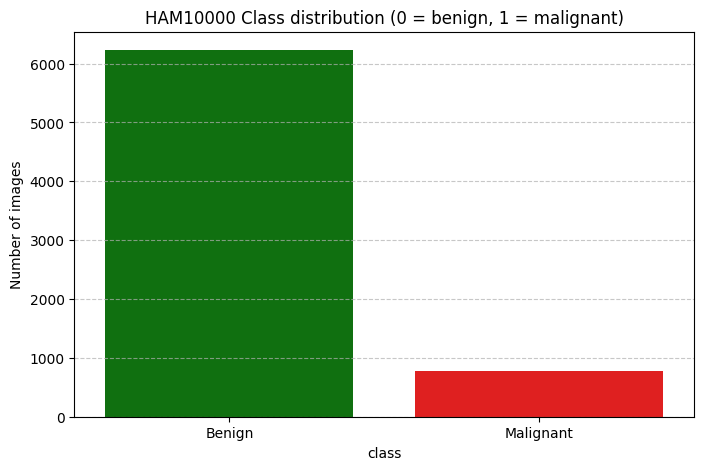

                age   sex localization
count   6973.000000  7010         7010
unique          NaN     3           15
top             NaN  male         back
freq            NaN  3792         1527
mean      51.890865   NaN          NaN
std       17.007532   NaN          NaN
min        0.000000   NaN          NaN
25%       40.000000   NaN          NaN
50%       50.000000   NaN          NaN
75%       65.000000   NaN          NaN
max       85.000000   NaN          NaN


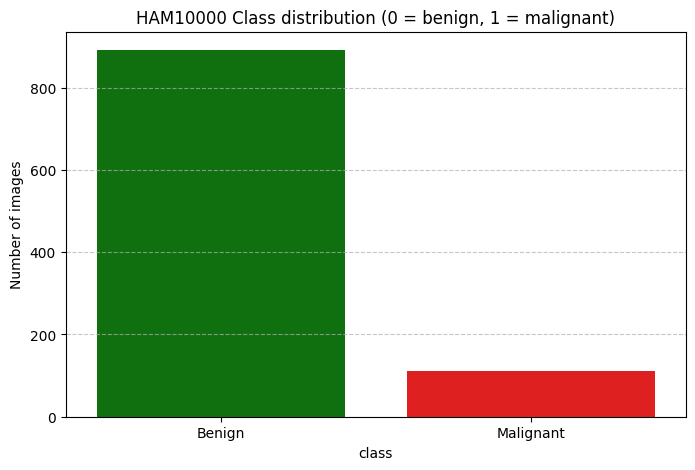

               age   sex     localization
count   995.000000  1002             1002
unique         NaN     3               14
top            NaN  male  lower extremity
freq           NaN   526              221
mean     51.467337   NaN              NaN
std      16.771865   NaN              NaN
min       0.000000   NaN              NaN
25%      40.000000   NaN              NaN
50%      50.000000   NaN              NaN
75%      65.000000   NaN              NaN
max      85.000000   NaN              NaN


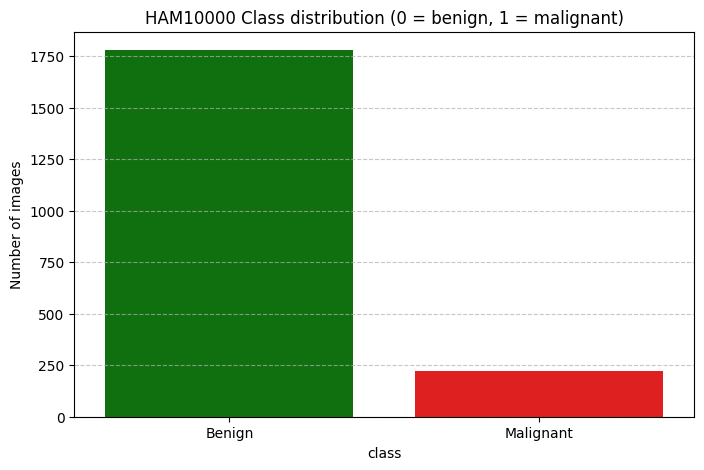

                age   sex localization
count   1990.000000  2003         2003
unique          NaN     3           14
top             NaN  male         back
freq            NaN  1088          468
mean      51.967337   NaN          NaN
std       16.935581   NaN          NaN
min        0.000000   NaN          NaN
25%       40.000000   NaN          NaN
50%       50.000000   NaN          NaN
75%       65.000000   NaN          NaN
max       85.000000   NaN          NaN


In [53]:
#explore splits
dataset = [train_df, val_df, test_df]


for df_split in dataset:
  plotClassDistribution(df_split)
  print(df_split[["age", "sex", "localization"]].describe(include="all"))

# Data preprocessing

In [54]:
# EfficientNet-B0 will 224x224 andere resolution sind auch möglich und ImageNet-Normalisierung

# define image tranformations for train and test/validation set
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # avoid overfitting in training data
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## function for searching images from drive
def find_image_path(img_id, directories):
    img_name = img_id + '.jpg'
    for directory in directories:
        path = os.path.join(directory, img_name)
        if os.path.exists(path):
            return path
    return None

# Dataset class
class SkinDataset(Dataset):
    def __init__(self, dataframe, img_dirs, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dirs = img_dirs
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_id = self.data.loc[idx, 'image_id']
        img_name = img_id + '.jpg'
        img_path = None

        # search in both folders (part 1&2) for the image
        img_path = find_image_path(img_id, self.img_dirs)

        if img_path is None:
            raise FileNotFoundError(f"Bild {img_name} nicht gefunden!")

        image = Image.open(img_path).convert('RGB')
        label = self.data.loc[idx, 'label']

        if self.transform:
            image = self.transform(image)

        # PyTorch expects labels as Float for binary loss (BCEWithLogitsLoss)
        return image, torch.tensor(label, dtype=torch.float32), img_id



# create data sets
train_dataset = SkinDataset(train_df, data_raw, transform=train_transforms)
val_dataset = SkinDataset(val_df, data_raw, transform=test_transforms)
test_dataset = SkinDataset(test_df, data_raw, transform=test_transforms)

# create data loader
b_size = 32
train_loader = DataLoader(train_dataset, batch_size=b_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=b_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=b_size, shuffle=False)

Loading original image with id: ISIC_0028398.jpg ...


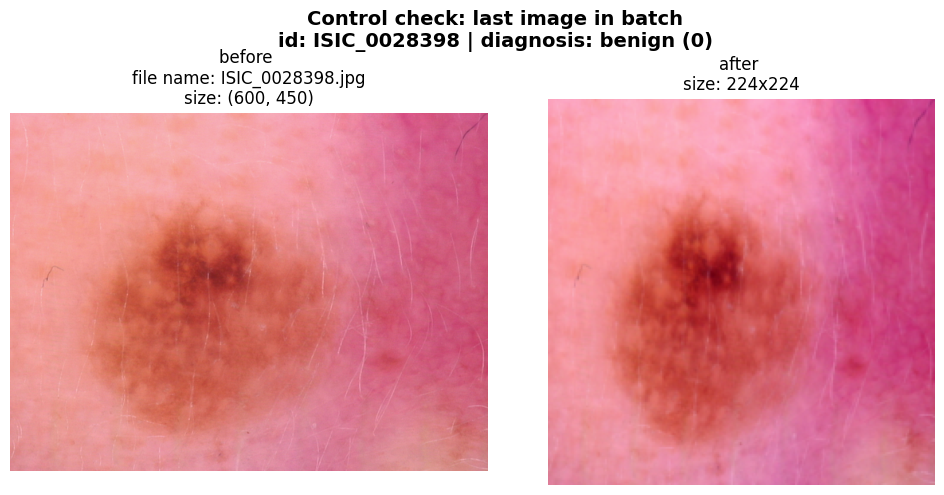

Searched for id: ISIC_0028398
ID from csv:
          image_id  label
4894  ISIC_0028398      0

 Matches csv
finished


In [55]:
### Example output
images, labels, image_ids = next(iter(train_loader))


tensor_img = images[-1]
label = labels[-1]
last_id = image_ids[-1]  # Das ist z.B. "ISIC_0024306"

print(f"Loading original image with id: {last_id}.jpg ...")

# image after transformation
img_np = tensor_img.numpy().transpose((1, 2, 0))
#mean = np.array([0.485, 0.456, 0.406])
#std = np.array([0.229, 0.224, 0.225])
#bild_np = std * bild_np + mean
minimum = img_np.min()
maximum = img_np.max()
img_np = (img_np - minimum) / (maximum - minimum)

# original image
img_name = last_id + '.jpg'
original_path = find_image_path(last_id, data_raw)

# show images
if original_path:
    original_image = Image.open(original_path).convert('RGB')
    label_name = "malignant (1)" if label.item() == 1.0 else "benign (0)"

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(f"Control check: last image in batch\nid: {last_id} | diagnosis: {label_name}", fontsize=14, fontweight='bold')

    axes[0].imshow(original_image)
    axes[0].set_title(f"before \nfile name: {img_name}\nsize: {original_image.size}", fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(img_np)
    axes[1].set_title(f"after \nsize: {tensor_img.shape[1]}x{tensor_img.shape[2]}", fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f"Error: {img_name} could not be found!")

check_row = df_metadata[df_metadata['image_id'] == last_id]

print(f"Searched for id: {last_id}")
print(f"ID from csv:\n{check_row[['image_id', 'label']]}")

# additional check
csv_label = check_row['label'].values[0]
batch_label = int(label.item())

if csv_label == batch_label:
    print("\n Matches csv")
else:
    print("\n Differs from csv")

print("finished")